# Week 1 — The hypothesis-testing agent (NumPy)

Everything in Week 1, built from `numpy` primitives. Nothing is hidden inside a
library call.

Run the cells in order. The exercises at the bottom are the ones from the
lesson pages; the solutions are on the website, so try them here first.

**Contents**
1. Bayes with states and observations
2. The evidence sum, and what it costs
3. Explaining away, and what mean-field loses
4. Homeostasis: a body that acts, and one that does not

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

## 1. Bayes with states and observations

The likelihood array `A` has observations down the **rows** and states across the
**columns**, so `A[i, j] = P(o = i | s = j)`. Each column is a distribution over
observations and therefore sums to one. Each row is a likelihood read as a
function of the state and has no reason to sum to anything.

In [2]:
STATES = ['leopard', 'baboon', 'nothing']
OBS    = ['tawny flash', 'branch shakes', 'quiet']

A = np.array([
    [0.70, 0.15, 0.02],   # tawny flash
    [0.25, 0.75, 0.08],   # branch shakes
    [0.05, 0.10, 0.90],   # quiet
])

prior = np.array([0.08, 0.22, 0.70])

print('column sums (must all be 1):', A.sum(axis=0))
print('row sums    (no reason to be 1):', A.sum(axis=1))

column sums (must all be 1): [1. 1. 1.]
row sums    (no reason to be 1): [0.87 1.08 1.05]


In [3]:
def posterior(A, prior, o):
    """Bayes for a discrete model. Returns the posterior and the evidence P(o)."""
    unnormalised = A[o] * prior          # elementwise: P(o|s) P(s), one per state
    evidence = unnormalised.sum()        # the sum over every state in the model
    return unnormalised / evidence, evidence


for o, name in enumerate(OBS):
    post, ev = posterior(A, prior, o)
    surprise = -np.log(ev)
    info = np.sum(post * np.log(post / prior))     # D_KL[posterior || prior]
    print(f'{name:>14} | P(o)={ev:.4f}  surprise={surprise:.3f} nats'
          f'  info gained={info:.3f} nats')
    shown = '  '.join(f'{n}={v:.4f}' for n, v in zip(STATES, post))
    print(f'{"":>14} | posterior  {shown}')

   tawny flash | P(o)=0.1030  surprise=2.273 nats  info gained=0.940 nats
               | posterior  leopard=0.5437  baboon=0.3204  nothing=0.1359
 branch shakes | P(o)=0.2410  surprise=1.423 nats  info gained=0.524 nats
               | posterior  leopard=0.0830  baboon=0.6846  nothing=0.2324
         quiet | P(o)=0.6560  surprise=0.422 nats  info gained=0.225 nats
               | posterior  leopard=0.0061  baboon=0.0335  nothing=0.9604


Those are the numbers quoted in Lesson 3. A tawny flash takes the leopard
hypothesis from 8% to 54%: not because leopards became likely, but because
nothing else explains tawny flashes.

### The ambiguity slider, in code

Blend the likelihood towards uniform and watch the observation stop telling you
anything.

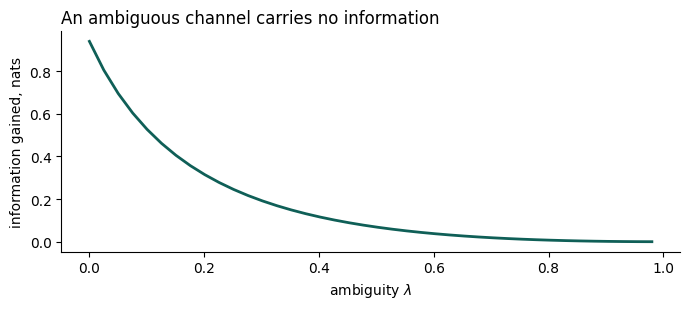

In [4]:
def blur(A, lam):
    """lam=0 leaves A alone; lam=1 makes every state predict every observation equally."""
    B = (1 - lam) * A + lam / A.shape[0]
    return B / B.sum(axis=0, keepdims=True)      # keep the columns normalised

lams = np.linspace(0, 0.98, 40)
info = [np.sum(posterior(blur(A, l), prior, 0)[0]
               * np.log(posterior(blur(A, l), prior, 0)[0] / prior)) for l in lams]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(lams, info, color='#0f5f57', lw=2)
ax.set_xlabel('ambiguity $\\lambda$'); ax.set_ylabel('information gained, nats')
ax.set_title('An ambiguous channel carries no information', loc='left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 2. What the evidence sum costs

`P(o)` requires visiting every state the model admits. With `n` factors of `k`
values each, that is `k**n` terms.

In [5]:
for n in (5, 10, 20, 40, 89):
    terms = 2.0 ** n
    secs = terms / 1e9                      # one addition per nanosecond, generous
    print(f'{n:>3} binary factors -> {terms:.3e} terms, {secs:.3e} s at 1e9 add/s')

print()
print('age of the universe in seconds ~ 4.35e17')
print('so 89 binary factors already exceeds it.')

  5 binary factors -> 3.200e+01 terms, 3.200e-08 s at 1e9 add/s
 10 binary factors -> 1.024e+03 terms, 1.024e-06 s at 1e9 add/s
 20 binary factors -> 1.049e+06 terms, 1.049e-03 s at 1e9 add/s
 40 binary factors -> 1.100e+12 terms, 1.100e+03 s at 1e9 add/s
 89 binary factors -> 6.190e+26 terms, 6.190e+17 s at 1e9 add/s

age of the universe in seconds ~ 4.35e17
so 89 binary factors already exceeds it.


## 2b. The count is not the cost

Lesson 5 claims a sum with astronomically many terms can be exact and cheap
if the model factorises, and that the count of terms therefore proves very
little. Here is that claim, run.

A chain of `n` factors with `k` values each. Brute force enumerates all `k**n`
joint states. Variable elimination pushes each factor as far right as it will
go and sums one variable at a time, at `k**2` per step. Both are exact, and
they should agree to the last bit.

In [6]:
import itertools, time
import numpy as np


def chain(k, n, seed=1):
    rng = np.random.default_rng(seed)
    return [rng.random((k, k)) for _ in range(n - 1)], rng.random(k)


def brute(fac, p0, k, n):
    total = 0.0
    for a in itertools.product(range(k), repeat=n):
        t = p0[a[0]]
        for i in range(n - 1):
            t *= fac[i][a[i], a[i + 1]]
        total += t
    return total


def eliminate(fac, p0, n):
    m = p0.copy()
    for i in range(n - 1):
        m = m @ fac[i]          # sum out one variable: k**2 multiply-adds
    return m.sum()


k = 4
print(f"{'n':>3} {'terms':>12} {'brute (ms)':>11} {'elim (ms)':>10} {'ops':>6}  agree")
for n in (4, 6, 8, 10, 12):
    fac, p0 = chain(k, n)
    t0 = time.perf_counter(); b = brute(fac, p0, k, n)
    tb = (time.perf_counter() - t0) * 1e3
    t0 = time.perf_counter(); e = eliminate(fac, p0, n)
    te = (time.perf_counter() - t0) * 1e3
    print(f'{n:>3} {k**n:>12,} {tb:>11.2f} {te:>10.4f} {(n-1)*k*k:>6}  '
          f'{abs(b - e) / b < 1e-12}')

  n        terms  brute (ms)  elim (ms)    ops  agree
  4          256        0.16     0.0275     48  True
  6        4,096        3.68     0.0133     80  True
  8       65,536       78.23     0.0346    112  True


 10    1,048,576     1566.26     0.0663    144  True


 12   16,777,216    29207.70     0.0410    176  True


The timings are this machine's and will differ on yours; the operation counts
will not, and they are what the argument rests on.

Extrapolate the brute-force column and compare against elimination, which is
linear in `n` and does not need extrapolating.

In [7]:
ns = np.array([4, 6, 8, 10, 12])
ms = []
for n in ns:
    fac, p0 = chain(k, n)
    t0 = time.perf_counter(); brute(fac, p0, k, n)
    ms.append((time.perf_counter() - t0) * 1e3)

slope, intercept = np.polyfit(ns, np.log(ms), 1)
print(f'brute force grows by a factor of {np.exp(slope):.2f} per extra variable')
print(f'                        against k = {k}, as the k**n law predicts\n')

for n in (20, 30, 40):
    years = np.exp(slope * n + intercept) / 1e3 / 3600 / 24 / 365.25
    print(f'  n={n:>3}  brute force ~ {years:.2e} years, {k**n:.2e} terms'
          f'   | elimination {(n-1)*k*k:>4} operations')

brute force grows by a factor of 4.53 per extra variable
                        against k = 4, as the k**n law predicts

  n= 20  brute force ~ 1.73e-01 years, 1.10e+12 terms   | elimination  304 operations
  n= 30  brute force ~ 6.28e+05 years, 1.15e+18 terms   | elimination  464 operations
  n= 40  brute force ~ 2.28e+12 years, 1.21e+24 terms   | elimination  624 operations


The extrapolation is the point of the lesson in one line: at `n = 40` the sum
has more terms than a mountain has atoms, and 624 multiply-adds return its
exact value.

Now break it. Couple every variable to every other and the elimination trick
has nothing to push right: summing out any variable produces a function of all
the rest. The cost is `k**(w+1)` with `w` the treewidth, and a dense model has
`w = n - 1`.

In [8]:
def elimination_cost(n, k, w):
    return n * k ** (w + 1)


for name, n, w in (('chain / any tree', 40, 1),
                   ('6x6 grid',         36, 6),
                   ('densely coupled',  40, 39)):
    c, bf = elimination_cost(n, k, w), k ** n
    verdict = 'no better than brute force' if c >= bf else f'{c:.3e}'
    print(f'{name:<18} n={n:<3} w={w:<3} elimination {verdict:>26}'
          f'   brute force {bf:.3e}')

chain / any tree   n=40  w=1   elimination                  6.400e+02   brute force 1.209e+24
6x6 grid           n=36  w=6   elimination                  5.898e+05   brute force 4.722e+21
densely coupled    n=40  w=39  elimination no better than brute force   brute force 1.209e+24


The middle row is the one to sit with. A grid's treewidth grows like the square
root of the number of variables, so exact inference stays exponential but in
`sqrt(n)`, which is the difference between hopeless and merely expensive.

And the bottom row is the honest case for an agent, because *explaining away*
(section 3 above) manufactures exactly this coupling: independent causes become
dependent the moment a shared effect is observed. A model assembled from
independent parts can have a densely coupled posterior.

## 3. What mean-field loses to explaining away

Two independent causes, either of which can shake a branch. Independent priors,
a shared observation, and a posterior that is anything but independent.

In [9]:
import itertools

p_cause, strength, leak = 0.1, 0.9, 0.01

def noisy_or(s):
    """P(o=1 | s) for a vector of binary causes."""
    return 1 - np.prod([1 - strength * x for x in s]) * (1 - leak)

def joint_posterior(n_causes):
    states = list(itertools.product([0, 1], repeat=n_causes))
    pri = np.array([np.prod([p_cause if x else 1 - p_cause for x in s]) for s in states])
    lik = np.array([noisy_or(s) for s in states])
    un = pri * lik
    return states, un / un.sum(), un.sum()

states, post, ev = joint_posterior(2)
print(f'P(o=1) = {ev:.6f}   surprise = {-np.log(ev):.4f} nats\n')
for s, p in zip(states, post):
    print(f'  gust={s[0]}  baboon={s[1]}   posterior={p:.4f}')

m1 = sum(p for s, p in zip(states, post) if s[0] == 1)
m2 = sum(p for s, p in zip(states, post) if s[1] == 1)
joint_11 = post[states.index((1, 1))]
print(f'\nmarginals: P(gust=1|o)={m1:.4f}  P(baboon=1|o)={m2:.4f}')
print(f'product of marginals at (1,1) = {m1*m2:.4f}')
print(f'true joint            at (1,1) = {joint_11:.4f}')
print(f'\nP(baboon=1 | gust=1, o) = {joint_11/m1:.4f}   <- the gust explains it away')
print(f'P(baboon=1 | gust=0, o) = {post[states.index((0,1))]/(1-m1):.4f}')

P(o=1) = 0.180181   surprise = 1.7138 nats

  gust=0  baboon=0   posterior=0.0450
  gust=0  baboon=1   posterior=0.4500
  gust=1  baboon=0   posterior=0.4500
  gust=1  baboon=1   posterior=0.0550

marginals: P(gust=1|o)=0.5050  P(baboon=1|o)=0.5050
product of marginals at (1,1) = 0.2550
true joint            at (1,1) = 0.0550

P(baboon=1 | gust=1, o) = 0.1088   <- the gust explains it away
P(baboon=1 | gust=0, o) = 0.9092


### How far off is the best factorised approximation?

The mean-field family cannot represent a correlated posterior at all. Measure the
gap in nats.

In [10]:
q = np.array([(1-m1)*(1-m2), m1*(1-m2), (1-m1)*m2, m1*m2])   # order: 00,10,01,11
p = np.array([post[states.index(s)] for s in [(0,0),(1,0),(0,1),(1,1)]])
print(f'D_KL[true posterior || product of marginals] = {np.sum(p*np.log(p/q)):.4f} nats')

print('\nExplaining away strengthens as causes are added:')
for n in (2, 3, 4, 5):
    st, po, _ = joint_posterior(n)
    marg = sum(pp for s, pp in zip(st, po) if s[0] == 1)
    print(f'  {n} causes: P(cause 1 = 1 | o) = {marg:.4f}')

D_KL[true posterior || product of marginals] = 0.3687 nats

Explaining away strengthens as causes are added:
  2 causes: P(cause 1 = 1 | o) = 0.5050
  3 causes: P(cause 1 = 1 | o) = 0.3615
  4 causes: P(cause 1 = 1 | o) = 0.2882
  5 causes: P(cause 1 = 1 | o) = 0.2439


## 4. Homeostasis: a body that acts, and one that does not

A two-dimensional random walk, absorbed at the unit circle. With `kappa = 0` it
is an unbiased walk and it always dies. With `kappa > 0` it does not diffuse at
all. Watch the entropy of the visited states, not the trajectory.

 no action, $\kappa=0$: died at step 257, final entropy 3.687 nats
 acting, $\kappa=0.15$: survived 4000 steps, final entropy 2.604 nats


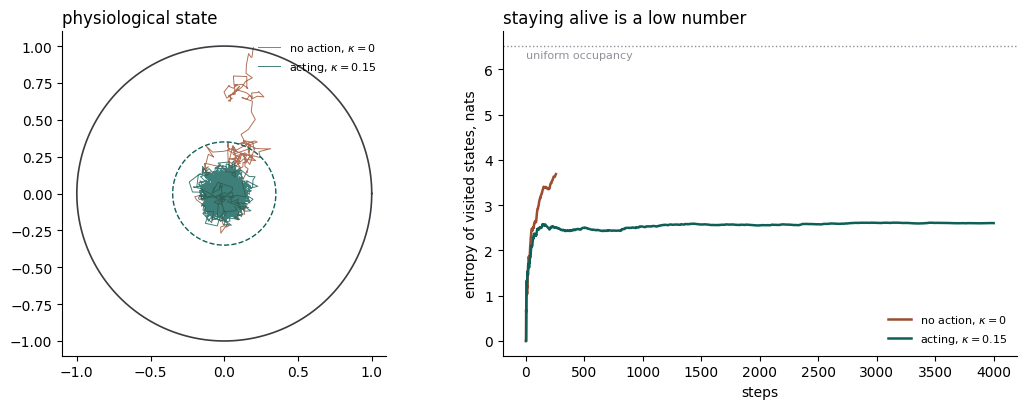

In [11]:
NB = 26                                   # histogram bins per axis
H_MAX = np.log(NB * NB)

def simulate(sigma=0.035, kappa=0.0, steps=4000, seed=None):
    r = np.random.default_rng(seed)
    x = np.zeros(2)
    bins = np.zeros((NB, NB))
    traj, ent = [], []
    for t in range(steps):
        x = x + sigma * r.normal(size=2) - kappa * x
        traj.append(x.copy())
        b = np.floor((x + 1) / 2 * NB).astype(int)
        if np.all((b >= 0) & (b < NB)):
            bins[b[1], b[0]] += 1
        q = bins / bins.sum()
        nz = q[q > 0]
        ent.append(-(nz * np.log(nz)).sum())
        if x @ x > 1:
            return np.array(traj), np.array(ent), t + 1     # absorbed
    return np.array(traj), np.array(ent), None              # survived

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for kappa, colour, label in [(0.0, '#9c4d2f', 'no action, $\\kappa=0$'),
                             (0.15, '#0f5f57', 'acting, $\\kappa=0.15$')]:
    traj, ent, died = simulate(kappa=kappa, seed=3)
    axes[0].plot(traj[:, 0], traj[:, 1], lw=0.7, color=colour, alpha=0.8, label=label)
    axes[1].plot(ent, color=colour, lw=1.8, label=label)
    print(f'{label:>22}: {"died at step " + str(died) if died else "survived 4000 steps"}, '
          f'final entropy {ent[-1]:.3f} nats')

theta = np.linspace(0, 2*np.pi, 200)
axes[0].plot(np.cos(theta), np.sin(theta), color='#3c3c42', lw=1.2)
axes[0].plot(0.35*np.cos(theta), 0.35*np.sin(theta), color='#0f5f57', lw=1, ls='--')
axes[0].set_aspect('equal'); axes[0].set_title('physiological state', loc='left')
axes[0].legend(fontsize=8, frameon=False)
axes[1].axhline(H_MAX, color='#90909a', ls=':', lw=1)
axes[1].text(0, H_MAX*0.96, 'uniform occupancy', fontsize=8, color='#90909a')
axes[1].set_xlabel('steps'); axes[1].set_ylabel('entropy of visited states, nats')
axes[1].set_title('staying alive is a low number', loc='left')
axes[1].legend(fontsize=8, frameon=False)
for a in axes: a.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

### The survival curve

Exercise 6 on the problems page asks you to predict, from dimensional analysis
alone, that lifetime scales as $\sigma^{-2}$. Here is the measurement. Predict
the slope before you run it.

fitted exponent = -1.863   (dimensional analysis predicts -2)


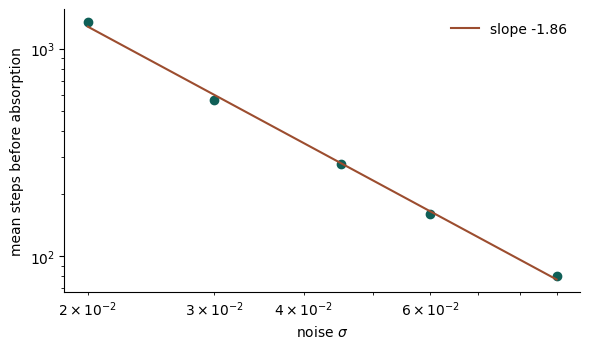

In [12]:
sigmas = np.array([0.02, 0.03, 0.045, 0.06, 0.09])
means = []
for s in sigmas:
    lives = [simulate(sigma=s, kappa=0.0, steps=20000, seed=i)[2] or 20000
             for i in range(60)]
    means.append(np.mean(lives))
means = np.array(means)

slope, intercept = np.polyfit(np.log(sigmas), np.log(means), 1)
print(f'fitted exponent = {slope:.3f}   (dimensional analysis predicts -2)')

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.loglog(sigmas, means, 'o', color='#0f5f57')
ax.loglog(sigmas, np.exp(intercept) * sigmas**slope, color='#9c4d2f', lw=1.5,
          label=f'slope {slope:.2f}')
ax.set_xlabel('noise $\\sigma$'); ax.set_ylabel('mean steps before absorption')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## Over to you

1. Change `prior` to the nervous hiker's `[0.40, 0.30, 0.30]` and recompute the
   surprise of *quiet*. Why is the nervous hiker more surprised by silence?
2. Build a two-state, three-observation model in which the rarest observation
   carries **zero** information. (Hint: make one row of `A` constant.)
3. In the noisy-OR model, set `strength = 0` so the observation is uninformative.
   Predict what happens to the mean-field gap before running it.
4. Add a third dimension to the homeostasis simulation. Does the lifetime scaling
   change? Should it?